In [1]:
pip install yfinance scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Fetch data for Tesla from Yahoo Finance
stock_data = yf.download('TSLA', start='2015-01-01', end='2021-01-01')

# Display the first few rows of the data
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [4]:
# Create the target variable (Next Close price)
stock_data['Next Close'] = stock_data['Close'].shift(-1)

# Drop the last row as it has a NaN value for 'Next Close'
stock_data = stock_data.dropna()

# Features (X) and Target (y)
X = stock_data[['Open', 'High', 'Low', 'Volume']]  # Features
y = stock_data['Next Close']  # Target variable

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the training and testing sets
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1208, 4) (1208,)
(302, 4) (302,)


In [6]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Make predictions on the test data
y_pred = model.predict(X_test)

In [8]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 6.282643559920631


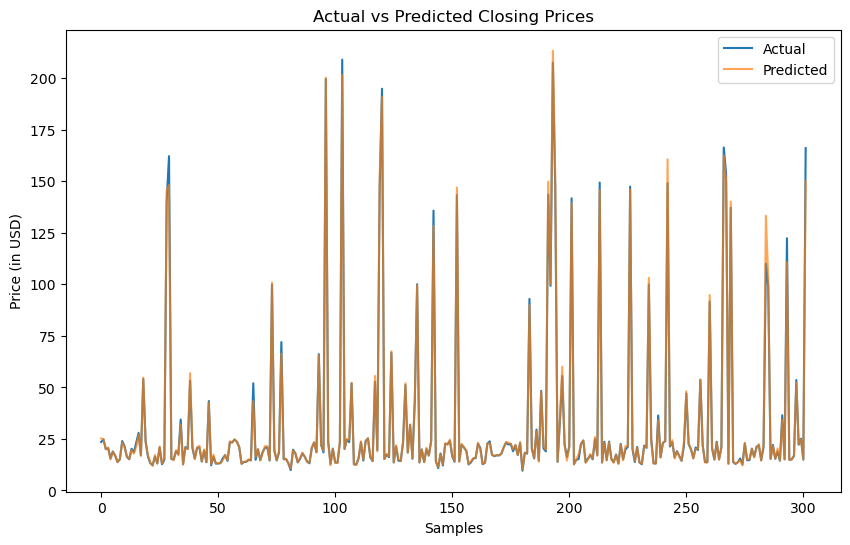

In [9]:
# Plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Samples')
plt.ylabel('Price (in USD)')
plt.show()